Dataset generado: (5000, 17)


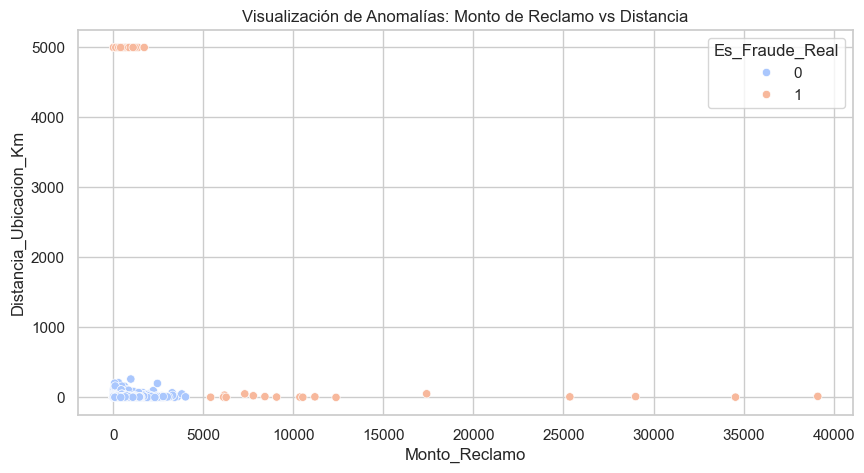


--- Clasificación de Riesgo en Transacciones Sospechosas ---
   ID_Transaccion  Monto_Reclamo  Probabilidad_Riesgo  Nivel_Riesgo
0               1    1842.072285             0.439753  Riesgo Medio
1               2    2106.404712             0.500285  Riesgo Medio
2               3    6175.058457             0.638562  Riesgo Medio
3               4    3372.643572             0.622959  Riesgo Medio
4               5    2843.050892             0.790937   Riesgo Alto
5               6   10363.071349             0.855872   Riesgo Alto
6               7   10526.024008             0.771825   Riesgo Alto
7               8   17402.135046             0.816675   Riesgo Alto
8               9    5407.842125             0.629058  Riesgo Medio
9              10     758.935095             0.592324  Riesgo Medio

--- Métricas de Evaluación ---
[[4877   72]
 [  23   28]]
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      4949
           1       0.2

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Configuración visual
sns.set(style="whitegrid")
np.random.seed(42)

# =============================================================================
# 1. SIMULACIÓN DE BASE DE DATOS PROFESIONAL (15 VARIABLES)
# =============================================================================
n_samples = 5000

data = {
    'ID_Transaccion': range(1, n_samples + 1),
    'Monto_Prima': np.random.normal(200, 50, n_samples),
    'Monto_Reclamo': np.random.exponential(500, n_samples),
    'Frecuencia_Reclamos_Anual': np.random.poisson(1, n_samples),
    'Ingreso_Mensual': np.random.normal(3500, 1000, n_samples),
    'Score_Crediticio': np.random.normal(700, 80, n_samples),
    'Antiguedad_Meses': np.random.randint(1, 120, n_samples),
    'Num_Cuentas_Vinculadas': np.random.randint(1, 5, n_samples),
    'Transacciones_Mes_Banca': np.random.randint(5, 60, n_samples),
    'Distancia_Ubicacion_Km': np.random.lognormal(2, 1, n_samples), # Distancia de la transacción
    'Hora_Transaccion': np.random.randint(0, 24, n_samples),
    'Cambio_Beneficiario_Reciente': np.random.choice([0, 1], n_samples, p=[0.95, 0.05]),
    'Metodo_Pago': np.random.choice(['App', 'Web', 'Presencial', 'ATM'], n_samples),
    'Tipo_Seguro': np.random.choice(['Auto', 'Vida', 'Salud', 'Hogar'], n_samples),
    'Monto_Ultimo_Pago_Banca': np.random.normal(150, 40, n_samples),
    'Dispositivo_Nuevo': np.random.choice([0, 1], n_samples, p=[0.9, 0.1])
}

df = pd.DataFrame(data)

# --- INYECCIÓN MANUAL DE ANOMALÍAS (Patrones de Fraude) ---
# Caso 1: Reclamo masivo con ingreso bajo
df.loc[0:25, 'Monto_Reclamo'] = df.loc[0:25, 'Monto_Reclamo'] * 20
df.loc[0:25, 'Ingreso_Mensual'] = 500

# Caso 2: Transacciones a distancias imposibles en horas extrañas
df.loc[26:50, 'Distancia_Ubicacion_Km'] = 5000
df.loc[26:50, 'Hora_Transaccion'] = 3

# Etiqueta real (Ground Truth) solo para evaluación final
df['Es_Fraude_Real'] = 0
df.loc[0:50, 'Es_Fraude_Real'] = 1 

print(f"Dataset generado: {df.shape}")

# =============================================================================
# 2. EDA (ANÁLISIS EXPLORATORIO)
# =============================================================================
# 
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='Monto_Reclamo', y='Distancia_Ubicacion_Km', hue='Es_Fraude_Real', palette='coolwarm')
plt.title("Visualización de Anomalías: Monto de Reclamo vs Distancia")
plt.show()

# =============================================================================
# 3. PREPROCESAMIENTO
# =============================================================================
# Codificación de variables categóricas
le = LabelEncoder()
df['Metodo_Pago_Enc'] = le.fit_transform(df['Metodo_Pago'])
df['Tipo_Seguro_Enc'] = le.fit_transform(df['Tipo_Seguro'])

# Selección de variables para el modelo (X)
features = ['Monto_Prima', 'Monto_Reclamo', 'Frecuencia_Reclamos_Anual', 'Ingreso_Mensual', 
            'Score_Crediticio', 'Distancia_Ubicacion_Km', 'Hora_Transaccion', 
            'Cambio_Beneficiario_Reciente', 'Metodo_Pago_Enc', 'Tipo_Seguro_Enc', 'Dispositivo_Nuevo']

X = df[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =============================================================================
# 4. MODELO DE DETECCIÓN DE ANOMALÍAS (ISOLATION FOREST)
# =============================================================================
# Contamination: Proporción esperada de anomalías (aprox 2% basado en fraude bancario)
iso_forest = IsolationForest(n_estimators=200, contamination=0.02, random_state=42)
df['Anomaly_Score'] = iso_forest.fit_predict(X_scaled)

# Isolation Forest devuelve -1 para anomalías y 1 para datos normales
# Lo convertimos a 1 para sospecha y 0 para normal
df['Prediccion_Anomalia'] = df['Anomaly_Score'].map({1: 0, -1: 1})

# Obtener la puntuación de decisión (mientras más bajo, más anómalo)
df['Decision_Score'] = iso_forest.decision_function(X_scaled)

# =============================================================================
# 5. ANÁLISIS DE RIESGO Y PROBABILIDADES
# =============================================================================
# Convertimos el Decision_Score en una probabilidad escalada [0, 1]
df['Probabilidad_Riesgo'] = 1 - ((df['Decision_Score'] - df['Decision_Score'].min()) / 
                                 (df['Decision_Score'].max() - df['Decision_Score'].min()))

def clasificar_riesgo(prob):
    if prob < 0.4: return 'Riesgo Bajo'
    elif prob < 0.7: return 'Riesgo Medio'
    else: return 'Riesgo Alto'

df['Nivel_Riesgo'] = df['Probabilidad_Riesgo'].apply(clasificar_riesgo)

print("\n--- Clasificación de Riesgo en Transacciones Sospechosas ---")
print(df[['ID_Transaccion', 'Monto_Reclamo', 'Probabilidad_Riesgo', 'Nivel_Riesgo']].head(10))

# =============================================================================
# 6. EVALUACIÓN DE MÉTRICAS
# =============================================================================
print("\n--- Métricas de Evaluación ---")
print(confusion_matrix(df['Es_Fraude_Real'], df['Prediccion_Anomalia']))
print(classification_report(df['Es_Fraude_Real'], df['Prediccion_Anomalia']))
print(f"ROC-AUC Score: {roc_auc_score(df['Es_Fraude_Real'], df['Probabilidad_Riesgo']):.4f}")

# =============================================================================
# 7. ANÁLISIS DE SENSIBILIDAD Y STRESS TEST
# =============================================================================
# Escenario de Estrés: ¿Qué pasa si el fraude se vuelve más sutil (montos menores)?
print("\n--- Stress Test: Fraude Sutil (Simulación) ---")
df_stress = X.copy()
# Reducimos los montos de reclamo fraudulentos a la mitad para ver si el modelo aún los detecta
df_stress.loc[0:50, 'Monto_Reclamo'] = df_stress.loc[0:50, 'Monto_Reclamo'] * 0.5
X_stress_scaled = scaler.transform(df_stress)
pred_stress = iso_forest.predict(X_stress_scaled)
anomalias_detectadas = (pred_stress == -1).sum()

print(f"Anomalías detectadas en escenario de estrés: {anomalias_detectadas}")
print(f"Eficacia en estrés: {(anomalias_detectadas/51)*100:.2f}%")

#